In [ ]:
# Support Vector Machines(SVM) - Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
dataset = pd.read_csv("polynomial_salary_data.csv")
dataset.head(3)

,Level,Salary
0,1,35805
1,2,20900
2,3,25480


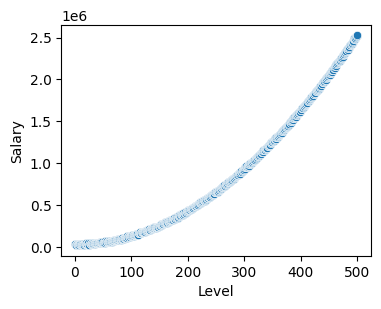

In [3]:
plt.figure(figsize=(4,3))
sns.scatterplot(x="Level", y="Salary", data=dataset)
plt.show()

In [4]:
dataset.isnull().sum()

Level     0
Salary    0
dtype: int64

In [5]:
x = dataset.iloc[:, :-1]
x

,Level
0,1
1,2
2,3
3,4
4,5
...,...
495,496
496,497
497,498
498,499


In [6]:
y = dataset["Salary"]
y

0        35805
1        20900
2        25480
3        32124
4        31534
        ...   
495    2485646
496    2498425
497    2504531
498    2521140
499    2527651
Name: Salary, Length: 500, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)

In [9]:
from sklearn.svm import SVR

In [10]:
sv = SVR(kernel="linear")
sv.fit(x_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [ ]:
# Kernel type:
#               'linear', 'poly', 'rbf', 'sigmoid'

In [11]:
sv.score(x_train, y_train)*100

93.11933117136115

In [12]:
sv.score(x_test, y_test)*100

92.80361406557807

In [ ]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf=sv)
plt.show()

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


In [ ]:
for i in range(1, 15):
    sv = SVR(kernel="linear")
    sv.fit(x_train, y_train)
    print(i, sv.score(x_train, y_train), sv.score(x_test, y_test))

In [ ]:
sns.scatterplot(x="Level", y="Salary", data=dataset)
plt.plot(dataset["Level"], sv.predict(x), color="red")
plt.show()